In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
from collections import defaultdict
from genomic_benchmarks.dataset_getters.pytorch_datasets import get_dataset
# Import the genomic benchmark dataset from Hugging Face
from genomic_benchmarks.dataset_getters.pytorch_datasets import DemoMouseEnhancers

# --------------------
# Data Preprocessing
# --------------------




    # Load the genomic benchmark dataset from Hugging Face
train_dset = get_dataset("demo_coding_vs_intergenomic_seqs", split="train", version=0)
test_dset  = get_dataset("demo_coding_vs_intergenomic_seqs", split="test", version=0)

    # Extract sequences and labels from the datasets
train_seqs = [item[0] for item in train_dset]
train_labels = [item[1] for item in train_dset]
test_seqs = [item[0] for item in test_dset]
test_labels = [item[1] for item in test_dset]

    



d:\Processed_PAR_Audio_Cookie\Processed_PAR_Audio_Cookie\.conda\Lib\site-packages\genomic_benchmarks\utils\datasets.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
import pandas as pd
# converting the lists to train and test csv
train_df = pd.DataFrame({
    'sequence':train_seqs,
    'target': train_labels
})

In [3]:
test_df = pd.DataFrame({
    'sequence':test_seqs,
    'target': test_labels
})

In [4]:
!pip install huggingface_hub[hf_extras]

In [5]:
!pip install faiss-cpu

In [6]:
!pip install scipy scikit-learn

In [7]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModel
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("LongSafari/hyenadna-large-1m-seqlen-hf", trust_remote_code=True)

# Load model using EsmModel
model =  AutoModel.from_pretrained("LongSafari/hyenadna-large-1m-seqlen-hf", trust_remote_code=True).to(device)

def embed_sequence(seq):
    inputs = tokenizer(seq, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs[0].mean(dim=1).squeeze().cpu().numpy() 
import time

# Start timer
start_time = time.time()
# Generate embeddings for train/test sequences
train_df["embedding"] = train_df["sequence"].apply(embed_sequence)
test_df["embedding"] = test_df["sequence"].apply(embed_sequence)
import faiss
import numpy as np

# Convert embeddings to numpy arrays
train_embeddings = np.stack(train_df["embedding"].values)
test_embeddings = np.stack(test_df["embedding"].values)

# Build FAISS index
dim = train_embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(train_embeddings)
k = 5  # Number of neighbors to retrieve

# Retrieve nearest neighbors for test data
_, indices = index.search(test_embeddings, k)

# Get labels of retrieved training examples
retrieved_labels = train_df.iloc[indices.flatten()]["target"].values.reshape(-1, k)
# Example: Majority voting
from scipy.stats import mode

predicted_labels, _ = mode(retrieved_labels, axis=1)
predicted_labels = predicted_labels.squeeze()
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

true_labels = test_df["target"].values
print(f"Accuracy: {accuracy_score(true_labels, predicted_labels):.4f}")
print(f"Precision: {precision_score(true_labels, predicted_labels, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(true_labels, predicted_labels, average='weighted'):.4f}")
print(f"Recall: {recall_score(true_labels, predicted_labels, average='weighted'):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(true_labels, predicted_labels))
end_time = time.time()
elapsed = end_time - start_time

# Report time
print(f"\n🕒 Evaluation took {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

Accuracy: 0.8249
Precision: 0.8257
F1-Score: 0.8248
Recall: 0.8249

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83     12500
           1       0.84      0.80      0.82     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000


🕒 Evaluation took 727.10 seconds (12.12 minutes)


In [8]:
import numpy as np
import faiss
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# =============================================================================
# 1. Define Feature Extraction Functions
# =============================================================================

def compute_gc_content(seq):
    """
    Compute GC content (% of G and C bases) for a DNA/RNA sequence.
    Returns a fraction (between 0 and 1).
    """
    seq = seq.upper()
    count = sum(seq.count(base) for base in ['A', 'C', 'G', 'T'])
    if count == 0:
        return 0
    return (seq.count('G') + seq.count('C')) / count

def compute_zcurve(seq):
    """
    Compute the zCurve features:
      x = (A+G) - (C+T)
      y = (A+C) - (G+T)
      z = (A+T) - (G+C)
    Returns a numpy array with 3 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    C = seq.count('C')
    G = seq.count('G')
    T = seq.count('T')
    x = (A + G) - (C + T)
    y = (A + C) - (G + T)
    z = (A + T) - (G + C)
    return np.array([x, y, z], dtype=float)

def compute_atgc_ratio(seq):
    """
    Compute the ratio (A+T) / (G+C).
    Returns a single numeric value (with safeguard for division by zero).
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    denom = G + C
    if denom == 0:
        return 0
    return (A + T) / denom

def compute_cumulative_skew(seq):
    """
    Compute two skew metrics:
      - gcSkew = (G - C)/(G+C)
      - atSkew = (A - T)/(A+T)
    Returns a numpy array with 2 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    gcSkew = (G - C) / (G + C) if (G + C) != 0 else 0
    atSkew = (A - T) / (A + T) if (A + T) != 0 else 0
    return np.array([gcSkew, atSkew], dtype=float)

def compute_pseudoKNC(seq, k=3):
    """
    A placeholder implementation for pseudoKNC:
      Count frequencies for all k-mers.
    For DNA with k=3, this creates a feature vector for all 4^3 = 64 k-mers.
    (The exact implementation for pseudoKNC may include additional biochemical properties.)
    """
    from itertools import product
    seq = seq.upper()
    kmer_list = [''.join(p) for p in product('ACGT', repeat=k)]
    counts = np.array([seq.count(kmer) for kmer in kmer_list], dtype=float)
    if counts.sum() != 0:
        counts /= counts.sum()  # Normalize to frequencies
    return counts



# =============================================================================
# 2. Create a Modular Feature Extraction Pipeline
# =============================================================================

def extract_features(seq, feature_functions):
    """
    Given a sequence and a list of functions,
    compute each feature and concatenate them into one feature vector.
    """
    features = []
    for func in feature_functions:
        feat = func(seq)
        # Ensure scalar outputs become 1D arrays
        if np.isscalar(feat):
            feat = np.array([feat])
        features.append(feat)
    return np.concatenate(features)
import time

# Start timer
start_time = time.time()
# Create a dictionary mapping names to feature extraction functions.
feature_functions = {
    'gcContent': compute_gc_content,         # 1 feature
    'zCurve': compute_zcurve,                  # 3 features
    'atgcRatio': compute_atgc_ratio,           # 1 feature
    'cumulativeSkew': compute_cumulative_skew, # 2 features
    'pseudoKNC': lambda seq: compute_pseudoKNC(seq, k=3)  # 64 features (example)
    # Add other functions as needed.
}

# Choose the features you want to try. For example:
# To try a combination of gcContent + zCurve:
selected_feature_keys = [ 'gcContent']
selected_functions = [feature_functions[key] for key in selected_feature_keys]

# =============================================================================
# 3. Compute and Normalize Extracted Features for Train and Test Data
# =============================================================================

# Assume train_df and test_df are already defined and contain a 'sequence' column.
train_features = train_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))
test_features = test_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))

# Convert from Series of arrays to a 2D numpy array
train_features = np.stack(train_features.values)
test_features = np.stack(test_features.values)

# Normalize the extracted features using MinMaxScaler
scaler_feat = MinMaxScaler()
train_features_scaled = scaler_feat.fit_transform(train_features)
test_features_scaled = scaler_feat.transform(test_features)

# =============================================================================
# 4. Combine with Precomputed Embeddings
# =============================================================================

def normalize_embeddings(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / norms

# Assume embeddings are stored in the 'embedding' column as arrays.
train_embeddings = normalize_embeddings(np.stack(train_df["embedding"].values))
test_embeddings = normalize_embeddings(np.stack(test_df["embedding"].values))

# Set weights for the combination; adjust as needed.
alpha_emb = 0.8# Weight for the original embeddings
beta_feat = 0.2 # Weight for the extracted features

train_combined = np.hstack([
    alpha_emb * train_embeddings,
    beta_feat * train_features_scaled
])
test_combined = np.hstack([
    alpha_emb * test_embeddings,
    beta_feat * test_features_scaled
])

# =============================================================================
# 5. Build FAISS Index and Define Retrieval + Voting Functions
# =============================================================================

# Build the FAISS index (using inner product, which is equivalent to cosine similarity on normalized vectors)
index = faiss.IndexFlatIP(train_combined.shape[1])
index.add(train_combined)



def batch_dynamic_retrieval(test_comb, base_k=5, sim_thr=0.7):
    """
    1) Retrieve top max_k neighbors for all queries in one FAISS call.
    2) Return distances, indices, and a boolean mask (use_expanded).
    """
    n = test_comb.shape[0]
    max_k = min(base_k * 2, train_combined.shape[0])

    # 1) Single batched FAISS search → shape (n, max_k)
    distances, indices = index.search(test_combined, max_k)

    # 2) Decide per-query whether to expand
    use_expanded = distances[:, :base_k].mean(axis=1) < sim_thr

    return distances, indices, use_expanded

# Run batch retrieval once
D_all, I_all, expand_mask = batch_dynamic_retrieval(test_combined, base_k=5, sim_thr=0.7)

# 3) Weighted voting with dynamic k in the loop
preds = []
for i, (D_full, I_full) in enumerate(zip(D_all, I_all)):
    if expand_mask[i]:
        D_i, I_i = D_full, I_full
    else:
        D_i, I_i = D_full[:5], I_full[:5]  # base_k=5
    weights = 1 / (1 + np.exp(-D_i))
    class_w = np.zeros(len(train_df['target'].unique()), dtype=float)
    for w, idx in zip(weights, I_i):
        class_w[ train_df.iloc[idx]['target'] ] += w
    preds.append(class_w.argmax())

# 4) Final evaluation
true_labels = test_df["target"]
print(f"Accuracy: {accuracy_score(true_labels, preds):.4f}")
print(f"Precision: {precision_score(true_labels, preds, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(true_labels, preds, average='weighted'):.4f}")
print(f"Recall: {recall_score(true_labels, preds, average='weighted'):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(true_labels, preds))
end_time = time.time()
elapsed = end_time - start_time

# Report time
print(f"\n🕒 Evaluation took {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

Accuracy: 0.7756
Precision: 0.7904
F1-Score: 0.7726
Recall: 0.7756

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.89      0.80     12500
           1       0.86      0.66      0.75     12500

    accuracy                           0.78     25000
   macro avg       0.79      0.78      0.77     25000
weighted avg       0.79      0.78      0.77     25000


🕒 Evaluation took 12.25 seconds (0.20 minutes)


In [9]:
import numpy as np
import faiss
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# =============================================================================
# 1. Define Feature Extraction Functions
# =============================================================================

def compute_gc_content(seq):
    """
    Compute GC content (% of G and C bases) for a DNA/RNA sequence.
    Returns a fraction (between 0 and 1).
    """
    seq = seq.upper()
    count = sum(seq.count(base) for base in ['A', 'C', 'G', 'T'])
    if count == 0:
        return 0
    return (seq.count('G') + seq.count('C')) / count

def compute_zcurve(seq):
    """
    Compute the zCurve features:
      x = (A+G) - (C+T)
      y = (A+C) - (G+T)
      z = (A+T) - (G+C)
    Returns a numpy array with 3 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    C = seq.count('C')
    G = seq.count('G')
    T = seq.count('T')
    x = (A + G) - (C + T)
    y = (A + C) - (G + T)
    z = (A + T) - (G + C)
    return np.array([x, y, z], dtype=float)

def compute_atgc_ratio(seq):
    """
    Compute the ratio (A+T) / (G+C).
    Returns a single numeric value (with safeguard for division by zero).
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    denom = G + C
    if denom == 0:
        return 0
    return (A + T) / denom

def compute_cumulative_skew(seq):
    """
    Compute two skew metrics:
      - gcSkew = (G - C)/(G+C)
      - atSkew = (A - T)/(A+T)
    Returns a numpy array with 2 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    gcSkew = (G - C) / (G + C) if (G + C) != 0 else 0
    atSkew = (A - T) / (A + T) if (A + T) != 0 else 0
    return np.array([gcSkew, atSkew], dtype=float)

def compute_pseudoKNC(seq, k=3):
    """
    A placeholder implementation for pseudoKNC:
      Count frequencies for all k-mers.
    For DNA with k=3, this creates a feature vector for all 4^3 = 64 k-mers.
    (The exact implementation for pseudoKNC may include additional biochemical properties.)
    """
    from itertools import product
    seq = seq.upper()
    kmer_list = [''.join(p) for p in product('ACGT', repeat=k)]
    counts = np.array([seq.count(kmer) for kmer in kmer_list], dtype=float)
    if counts.sum() != 0:
        counts /= counts.sum()  # Normalize to frequencies
    return counts



# =============================================================================
# 2. Create a Modular Feature Extraction Pipeline
# =============================================================================

def extract_features(seq, feature_functions):
    """
    Given a sequence and a list of functions,
    compute each feature and concatenate them into one feature vector.
    """
    features = []
    for func in feature_functions:
        feat = func(seq)
        # Ensure scalar outputs become 1D arrays
        if np.isscalar(feat):
            feat = np.array([feat])
        features.append(feat)
    return np.concatenate(features)
import time

# Start timer
start_time = time.time()
# Create a dictionary mapping names to feature extraction functions.
feature_functions = {
    'gcContent': compute_gc_content,         # 1 feature
    'zCurve': compute_zcurve,                  # 3 features
    'atgcRatio': compute_atgc_ratio,           # 1 feature
    'cumulativeSkew': compute_cumulative_skew, # 2 features
    'pseudoKNC': lambda seq: compute_pseudoKNC(seq, k=3)  # 64 features (example)

}

# Choose the features you want to try.

selected_feature_keys = [ 'zCurve']
selected_functions = [feature_functions[key] for key in selected_feature_keys]

# =============================================================================
# 3. Compute and Normalize Extracted Features for Train and Test Data
# =============================================================================

# Assume train_df and test_df are already defined and contain a 'sequence' column.
train_features = train_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))
test_features = test_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))

# Convert from Series of arrays to a 2D numpy array
train_features = np.stack(train_features.values)
test_features = np.stack(test_features.values)

# Normalize the extracted features using MinMaxScaler
scaler_feat = MinMaxScaler()
train_features_scaled = scaler_feat.fit_transform(train_features)
test_features_scaled = scaler_feat.transform(test_features)

# =============================================================================
# 4. Combine with Precomputed Embeddings
# =============================================================================

def normalize_embeddings(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / norms

# Assume embeddings are stored in the 'embedding' column as arrays.
train_embeddings = normalize_embeddings(np.stack(train_df["embedding"].values))
test_embeddings = normalize_embeddings(np.stack(test_df["embedding"].values))

# Set weights for the combination; adjust as needed.
alpha_emb = 0.8# Weight for the original embeddings
beta_feat = 0.2 # Weight for the extracted features

train_combined = np.hstack([
    alpha_emb * train_embeddings,
    beta_feat * train_features_scaled
])
test_combined = np.hstack([
    alpha_emb * test_embeddings,
    beta_feat * test_features_scaled
])

# =============================================================================
# 5. Build FAISS Index and Define Retrieval + Voting Functions
# =============================================================================

# Build the FAISS index (using inner product, which is equivalent to cosine similarity on normalized vectors)
index = faiss.IndexFlatIP(train_combined.shape[1])
index.add(train_combined)



def batch_dynamic_retrieval(test_comb, base_k=5, sim_thr=0.7):
    """
    1) Retrieve top max_k neighbors for all queries in one FAISS call.
    2) Return distances, indices, and a boolean mask (use_expanded).
    """
    n = test_comb.shape[0]
    max_k = min(base_k * 2, train_combined.shape[0])

    # 1) Single batched FAISS search → shape (n, max_k)
    distances, indices = index.search(test_combined, max_k)

    # 2) Decide per-query whether to expand
    use_expanded = distances[:, :base_k].mean(axis=1) < sim_thr

    return distances, indices, use_expanded

# Run batch retrieval once
D_all, I_all, expand_mask = batch_dynamic_retrieval(test_combined, base_k=5, sim_thr=0.7)

# 3) Weighted voting with dynamic k in the loop
preds = []
for i, (D_full, I_full) in enumerate(zip(D_all, I_all)):
    if expand_mask[i]:
        D_i, I_i = D_full, I_full
    else:
        D_i, I_i = D_full[:5], I_full[:5]  # base_k=5
    weights = 1 / (1 + np.exp(-D_i))
    class_w = np.zeros(len(train_df['target'].unique()), dtype=float)
    for w, idx in zip(weights, I_i):
        class_w[ train_df.iloc[idx]['target'] ] += w
    preds.append(class_w.argmax())

# 4) Final evaluation
true_labels = test_df["target"]
print(f"Accuracy: {accuracy_score(true_labels, preds):.4f}")
print(f"Precision: {precision_score(true_labels, preds, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(true_labels, preds, average='weighted'):.4f}")
print(f"Recall: {recall_score(true_labels, preds, average='weighted'):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(true_labels, preds))
end_time = time.time()
elapsed = end_time - start_time

# Report time
print(f"\n🕒 Evaluation took {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

Accuracy: 0.7844
Precision: 0.7926
F1-Score: 0.7829
Recall: 0.7844

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.70      0.76     12500
           1       0.74      0.87      0.80     12500

    accuracy                           0.78     25000
   macro avg       0.79      0.78      0.78     25000
weighted avg       0.79      0.78      0.78     25000


🕒 Evaluation took 12.18 seconds (0.20 minutes)


In [10]:
import numpy as np
import faiss
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# =============================================================================
# 1. Define Feature Extraction Functions
# =============================================================================

def compute_gc_content(seq):
    """
    Compute GC content (% of G and C bases) for a DNA/RNA sequence.
    Returns a fraction (between 0 and 1).
    """
    seq = seq.upper()
    count = sum(seq.count(base) for base in ['A', 'C', 'G', 'T'])
    if count == 0:
        return 0
    return (seq.count('G') + seq.count('C')) / count

def compute_zcurve(seq):
    """
    Compute the zCurve features:
      x = (A+G) - (C+T)
      y = (A+C) - (G+T)
      z = (A+T) - (G+C)
    Returns a numpy array with 3 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    C = seq.count('C')
    G = seq.count('G')
    T = seq.count('T')
    x = (A + G) - (C + T)
    y = (A + C) - (G + T)
    z = (A + T) - (G + C)
    return np.array([x, y, z], dtype=float)

def compute_atgc_ratio(seq):
    """
    Compute the ratio (A+T) / (G+C).
    Returns a single numeric value (with safeguard for division by zero).
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    denom = G + C
    if denom == 0:
        return 0
    return (A + T) / denom

def compute_cumulative_skew(seq):
    """
    Compute two skew metrics:
      - gcSkew = (G - C)/(G+C)
      - atSkew = (A - T)/(A+T)
    Returns a numpy array with 2 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    gcSkew = (G - C) / (G + C) if (G + C) != 0 else 0
    atSkew = (A - T) / (A + T) if (A + T) != 0 else 0
    return np.array([gcSkew, atSkew], dtype=float)

def compute_pseudoKNC(seq, k=3):
    """
    A placeholder implementation for pseudoKNC:
      Count frequencies for all k-mers.
    For DNA with k=3, this creates a feature vector for all 4^3 = 64 k-mers.
    (The exact implementation for pseudoKNC may include additional biochemical properties.)
    """
    from itertools import product
    seq = seq.upper()
    kmer_list = [''.join(p) for p in product('ACGT', repeat=k)]
    counts = np.array([seq.count(kmer) for kmer in kmer_list], dtype=float)
    if counts.sum() != 0:
        counts /= counts.sum()  # Normalize to frequencies
    return counts



# =============================================================================
# 2. Create a Modular Feature Extraction Pipeline
# =============================================================================

def extract_features(seq, feature_functions):
    """
    Given a sequence and a list of functions,
    compute each feature and concatenate them into one feature vector.
    """
    features = []
    for func in feature_functions:
        feat = func(seq)
        # Ensure scalar outputs become 1D arrays
        if np.isscalar(feat):
            feat = np.array([feat])
        features.append(feat)
    return np.concatenate(features)
import time

# Start timer
start_time = time.time()
# Create a dictionary mapping names to feature extraction functions.
feature_functions = {
    'gcContent': compute_gc_content,         # 1 feature
    'zCurve': compute_zcurve,                  # 3 features
    'atgcRatio': compute_atgc_ratio,           # 1 feature
    'cumulativeSkew': compute_cumulative_skew, # 2 features
    'pseudoKNC': lambda seq: compute_pseudoKNC(seq, k=3)  # 64 features (example)

}

# Choose the features you want to try.

selected_feature_keys = ['atgcRatio']
selected_functions = [feature_functions[key] for key in selected_feature_keys]

# =============================================================================
# 3. Compute and Normalize Extracted Features for Train and Test Data
# =============================================================================

# Assume train_df and test_df are already defined and contain a 'sequence' column.
train_features = train_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))
test_features = test_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))

# Convert from Series of arrays to a 2D numpy array
train_features = np.stack(train_features.values)
test_features = np.stack(test_features.values)

# Normalize the extracted features using MinMaxScaler
scaler_feat = MinMaxScaler()
train_features_scaled = scaler_feat.fit_transform(train_features)
test_features_scaled = scaler_feat.transform(test_features)

# =============================================================================
# 4. Combine with Precomputed Embeddings
# =============================================================================

def normalize_embeddings(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / norms

# Assume embeddings are stored in the 'embedding' column as arrays.
train_embeddings = normalize_embeddings(np.stack(train_df["embedding"].values))
test_embeddings = normalize_embeddings(np.stack(test_df["embedding"].values))

# Set weights for the combination; adjust as needed.
alpha_emb = 0.8# Weight for the original embeddings
beta_feat = 0.2 # Weight for the extracted features

train_combined = np.hstack([
    alpha_emb * train_embeddings,
    beta_feat * train_features_scaled
])
test_combined = np.hstack([
    alpha_emb * test_embeddings,
    beta_feat * test_features_scaled
])

# =============================================================================
# 5. Build FAISS Index and Define Retrieval + Voting Functions
# =============================================================================

# Build the FAISS index (using inner product, which is equivalent to cosine similarity on normalized vectors)
index = faiss.IndexFlatIP(train_combined.shape[1])
index.add(train_combined)



def batch_dynamic_retrieval(test_comb, base_k=5, sim_thr=0.7):
    """
    1) Retrieve top max_k neighbors for all queries in one FAISS call.
    2) Return distances, indices, and a boolean mask (use_expanded).
    """
    n = test_comb.shape[0]
    max_k = min(base_k * 2, train_combined.shape[0])

    # 1) Single batched FAISS search → shape (n, max_k)
    distances, indices = index.search(test_combined, max_k)

    # 2) Decide per-query whether to expand
    use_expanded = distances[:, :base_k].mean(axis=1) < sim_thr

    return distances, indices, use_expanded

# Run batch retrieval once
D_all, I_all, expand_mask = batch_dynamic_retrieval(test_combined, base_k=5, sim_thr=0.7)

# 3) Weighted voting with dynamic k in the loop
preds = []
for i, (D_full, I_full) in enumerate(zip(D_all, I_all)):
    if expand_mask[i]:
        D_i, I_i = D_full, I_full
    else:
        D_i, I_i = D_full[:5], I_full[:5]  # base_k=5
    weights = 1 / (1 + np.exp(-D_i))
    class_w = np.zeros(len(train_df['target'].unique()), dtype=float)
    for w, idx in zip(weights, I_i):
        class_w[ train_df.iloc[idx]['target'] ] += w
    preds.append(class_w.argmax())

# 4) Final evaluation
true_labels = test_df["target"]
print(f"Accuracy: {accuracy_score(true_labels, preds):.4f}")
print(f"Precision: {precision_score(true_labels, preds, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(true_labels, preds, average='weighted'):.4f}")
print(f"Recall: {recall_score(true_labels, preds, average='weighted'):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(true_labels, preds))
end_time = time.time()
elapsed = end_time - start_time

# Report time
print(f"\n🕒 Evaluation took {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

Accuracy: 0.8305
Precision: 0.8318
F1-Score: 0.8303
Recall: 0.8305

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.84     12500
           1       0.85      0.80      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000


🕒 Evaluation took 12.18 seconds (0.20 minutes)


In [12]:
import numpy as np
import faiss
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# =============================================================================
# 1. Define Feature Extraction Functions
# =============================================================================

def compute_gc_content(seq):
    """
    Compute GC content (% of G and C bases) for a DNA/RNA sequence.
    Returns a fraction (between 0 and 1).
    """
    seq = seq.upper()
    count = sum(seq.count(base) for base in ['A', 'C', 'G', 'T'])
    if count == 0:
        return 0
    return (seq.count('G') + seq.count('C')) / count

def compute_zcurve(seq):
    """
    Compute the zCurve features:
      x = (A+G) - (C+T)
      y = (A+C) - (G+T)
      z = (A+T) - (G+C)
    Returns a numpy array with 3 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    C = seq.count('C')
    G = seq.count('G')
    T = seq.count('T')
    x = (A + G) - (C + T)
    y = (A + C) - (G + T)
    z = (A + T) - (G + C)
    return np.array([x, y, z], dtype=float)

def compute_atgc_ratio(seq):
    """
    Compute the ratio (A+T) / (G+C).
    Returns a single numeric value (with safeguard for division by zero).
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    denom = G + C
    if denom == 0:
        return 0
    return (A + T) / denom

def compute_cumulative_skew(seq):
    """
    Compute two skew metrics:
      - gcSkew = (G - C)/(G+C)
      - atSkew = (A - T)/(A+T)
    Returns a numpy array with 2 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    gcSkew = (G - C) / (G + C) if (G + C) != 0 else 0
    atSkew = (A - T) / (A + T) if (A + T) != 0 else 0
    return np.array([gcSkew, atSkew], dtype=float)

def compute_pseudoKNC(seq, k=3):
    """
    A placeholder implementation for pseudoKNC:
      Count frequencies for all k-mers.
    For DNA with k=3, this creates a feature vector for all 4^3 = 64 k-mers.
    (The exact implementation for pseudoKNC may include additional biochemical properties.)
    """
    from itertools import product
    seq = seq.upper()
    kmer_list = [''.join(p) for p in product('ACGT', repeat=k)]
    counts = np.array([seq.count(kmer) for kmer in kmer_list], dtype=float)
    if counts.sum() != 0:
        counts /= counts.sum()  # Normalize to frequencies
    return counts



# =============================================================================
# 2. Create a Modular Feature Extraction Pipeline
# =============================================================================

def extract_features(seq, feature_functions):
    """
    Given a sequence and a list of functions,
    compute each feature and concatenate them into one feature vector.
    """
    features = []
    for func in feature_functions:
        feat = func(seq)
        # Ensure scalar outputs become 1D arrays
        if np.isscalar(feat):
            feat = np.array([feat])
        features.append(feat)
    return np.concatenate(features)
import time

# Start timer
start_time = time.time()
# Create a dictionary mapping names to feature extraction functions.
feature_functions = {
    'gcContent': compute_gc_content,         # 1 feature
    'zCurve': compute_zcurve,                  # 3 features
    'atgcRatio': compute_atgc_ratio,           # 1 feature
    'cumulativeSkew': compute_cumulative_skew, # 2 features
    'pseudoKNC': lambda seq: compute_pseudoKNC(seq, k=3)  # 64 features (example)

}

# Choose the features you want to try.

selected_feature_keys = ['cumulativeSkew']
selected_functions = [feature_functions[key] for key in selected_feature_keys]

# =============================================================================
# 3. Compute and Normalize Extracted Features for Train and Test Data
# =============================================================================

# Assume train_df and test_df are already defined and contain a 'sequence' column.
train_features = train_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))
test_features = test_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))

# Convert from Series of arrays to a 2D numpy array
train_features = np.stack(train_features.values)
test_features = np.stack(test_features.values)

# Normalize the extracted features using MinMaxScaler
scaler_feat = MinMaxScaler()
train_features_scaled = scaler_feat.fit_transform(train_features)
test_features_scaled = scaler_feat.transform(test_features)

# =============================================================================
# 4. Combine with Precomputed Embeddings
# =============================================================================

def normalize_embeddings(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / norms

# Assume embeddings are stored in the 'embedding' column as arrays.
train_embeddings = normalize_embeddings(np.stack(train_df["embedding"].values))
test_embeddings = normalize_embeddings(np.stack(test_df["embedding"].values))

# Set weights for the combination; adjust as needed.
alpha_emb = 0.8# Weight for the original embeddings
beta_feat = 0.2 # Weight for the extracted features

train_combined = np.hstack([
    alpha_emb * train_embeddings,
    beta_feat * train_features_scaled
])
test_combined = np.hstack([
    alpha_emb * test_embeddings,
    beta_feat * test_features_scaled
])

# =============================================================================
# 5. Build FAISS Index and Define Retrieval + Voting Functions
# =============================================================================

# Build the FAISS index (using inner product, which is equivalent to cosine similarity on normalized vectors)
index = faiss.IndexFlatIP(train_combined.shape[1])
index.add(train_combined)



def batch_dynamic_retrieval(test_comb, base_k=5, sim_thr=0.7):
    """
    1) Retrieve top max_k neighbors for all queries in one FAISS call.
    2) Return distances, indices, and a boolean mask (use_expanded).
    """
    n = test_comb.shape[0]
    max_k = min(base_k * 2, train_combined.shape[0])

    # 1) Single batched FAISS search → shape (n, max_k)
    distances, indices = index.search(test_combined, max_k)

    # 2) Decide per-query whether to expand
    use_expanded = distances[:, :base_k].mean(axis=1) < sim_thr

    return distances, indices, use_expanded

# Run batch retrieval once
D_all, I_all, expand_mask = batch_dynamic_retrieval(test_combined, base_k=5, sim_thr=0.7)

# 3) Weighted voting with dynamic k in the loop
preds = []
for i, (D_full, I_full) in enumerate(zip(D_all, I_all)):
    if expand_mask[i]:
        D_i, I_i = D_full, I_full
    else:
        D_i, I_i = D_full[:5], I_full[:5]  # base_k=5
    weights = 1 / (1 + np.exp(-D_i))
    class_w = np.zeros(len(train_df['target'].unique()), dtype=float)
    for w, idx in zip(weights, I_i):
        class_w[ train_df.iloc[idx]['target'] ] += w
    preds.append(class_w.argmax())

# 4) Final evaluation
true_labels = test_df["target"]
print(f"Accuracy: {accuracy_score(true_labels, preds):.4f}")
print(f"Precision: {precision_score(true_labels, preds, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(true_labels, preds, average='weighted'):.4f}")
print(f"Recall: {recall_score(true_labels, preds, average='weighted'):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(true_labels, preds))
end_time = time.time()
elapsed = end_time - start_time

# Report time
print(f"\n🕒 Evaluation took {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

Accuracy: 0.7816
Precision: 0.7925
F1-Score: 0.7796
Recall: 0.7816

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.88      0.80     12500
           1       0.85      0.69      0.76     12500

    accuracy                           0.78     25000
   macro avg       0.79      0.78      0.78     25000
weighted avg       0.79      0.78      0.78     25000


🕒 Evaluation took 12.14 seconds (0.20 minutes)


In [13]:
import numpy as np
import faiss
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# =============================================================================
# 1. Define Feature Extraction Functions
# =============================================================================

def compute_gc_content(seq):
    """
    Compute GC content (% of G and C bases) for a DNA/RNA sequence.
    Returns a fraction (between 0 and 1).
    """
    seq = seq.upper()
    count = sum(seq.count(base) for base in ['A', 'C', 'G', 'T'])
    if count == 0:
        return 0
    return (seq.count('G') + seq.count('C')) / count

def compute_zcurve(seq):
    """
    Compute the zCurve features:
      x = (A+G) - (C+T)
      y = (A+C) - (G+T)
      z = (A+T) - (G+C)
    Returns a numpy array with 3 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    C = seq.count('C')
    G = seq.count('G')
    T = seq.count('T')
    x = (A + G) - (C + T)
    y = (A + C) - (G + T)
    z = (A + T) - (G + C)
    return np.array([x, y, z], dtype=float)

def compute_atgc_ratio(seq):
    """
    Compute the ratio (A+T) / (G+C).
    Returns a single numeric value (with safeguard for division by zero).
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    denom = G + C
    if denom == 0:
        return 0
    return (A + T) / denom

def compute_cumulative_skew(seq):
    """
    Compute two skew metrics:
      - gcSkew = (G - C)/(G+C)
      - atSkew = (A - T)/(A+T)
    Returns a numpy array with 2 values.
    """
    seq = seq.upper()
    A = seq.count('A')
    T = seq.count('T')
    G = seq.count('G')
    C = seq.count('C')
    gcSkew = (G - C) / (G + C) if (G + C) != 0 else 0
    atSkew = (A - T) / (A + T) if (A + T) != 0 else 0
    return np.array([gcSkew, atSkew], dtype=float)

def compute_pseudoKNC(seq, k=3):
    """
    A placeholder implementation for pseudoKNC:
      Count frequencies for all k-mers.
    For DNA with k=3, this creates a feature vector for all 4^3 = 64 k-mers.
    (The exact implementation for pseudoKNC may include additional biochemical properties.)
    """
    from itertools import product
    seq = seq.upper()
    kmer_list = [''.join(p) for p in product('ACGT', repeat=k)]
    counts = np.array([seq.count(kmer) for kmer in kmer_list], dtype=float)
    if counts.sum() != 0:
        counts /= counts.sum()  # Normalize to frequencies
    return counts



# =============================================================================
# 2. Create a Modular Feature Extraction Pipeline
# =============================================================================

def extract_features(seq, feature_functions):
    """
    Given a sequence and a list of functions,
    compute each feature and concatenate them into one feature vector.
    """
    features = []
    for func in feature_functions:
        feat = func(seq)
        # Ensure scalar outputs become 1D arrays
        if np.isscalar(feat):
            feat = np.array([feat])
        features.append(feat)
    return np.concatenate(features)
import time

# Start timer
start_time = time.time()
# Create a dictionary mapping names to feature extraction functions.
feature_functions = {
    'gcContent': compute_gc_content,         # 1 feature
    'zCurve': compute_zcurve,                  # 3 features
    'atgcRatio': compute_atgc_ratio,           # 1 feature
    'cumulativeSkew': compute_cumulative_skew, # 2 features
    'pseudoKNC': lambda seq: compute_pseudoKNC(seq, k=3)  # 64 features (example)

}

# Choose the features you want to try.

selected_feature_keys = ['pseudoKNC']
selected_functions = [feature_functions[key] for key in selected_feature_keys]

# =============================================================================
# 3. Compute and Normalize Extracted Features for Train and Test Data
# =============================================================================

# Assume train_df and test_df are already defined and contain a 'sequence' column.
train_features = train_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))
test_features = test_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))

# Convert from Series of arrays to a 2D numpy array
train_features = np.stack(train_features.values)
test_features = np.stack(test_features.values)

# Normalize the extracted features using MinMaxScaler
scaler_feat = MinMaxScaler()
train_features_scaled = scaler_feat.fit_transform(train_features)
test_features_scaled = scaler_feat.transform(test_features)

# =============================================================================
# 4. Combine with Precomputed Embeddings
# =============================================================================

def normalize_embeddings(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / norms

# Assume embeddings are stored in the 'embedding' column as arrays.
train_embeddings = normalize_embeddings(np.stack(train_df["embedding"].values))
test_embeddings = normalize_embeddings(np.stack(test_df["embedding"].values))

# Set weights for the combination; adjust as needed.
alpha_emb = 0.8# Weight for the original embeddings
beta_feat = 0.2 # Weight for the extracted features

train_combined = np.hstack([
    alpha_emb * train_embeddings,
    beta_feat * train_features_scaled
])
test_combined = np.hstack([
    alpha_emb * test_embeddings,
    beta_feat * test_features_scaled
])

# =============================================================================
# 5. Build FAISS Index and Define Retrieval + Voting Functions
# =============================================================================

# Build the FAISS index (using inner product, which is equivalent to cosine similarity on normalized vectors)
index = faiss.IndexFlatIP(train_combined.shape[1])
index.add(train_combined)



def batch_dynamic_retrieval(test_comb, base_k=5, sim_thr=0.7):
    """
    1) Retrieve top max_k neighbors for all queries in one FAISS call.
    2) Return distances, indices, and a boolean mask (use_expanded).
    """
    n = test_comb.shape[0]
    max_k = min(base_k * 2, train_combined.shape[0])

    # 1) Single batched FAISS search → shape (n, max_k)
    distances, indices = index.search(test_combined, max_k)

    # 2) Decide per-query whether to expand
    use_expanded = distances[:, :base_k].mean(axis=1) < sim_thr

    return distances, indices, use_expanded

# Run batch retrieval once
D_all, I_all, expand_mask = batch_dynamic_retrieval(test_combined, base_k=5, sim_thr=0.7)

# 3) Weighted voting with dynamic k in the loop
preds = []
for i, (D_full, I_full) in enumerate(zip(D_all, I_all)):
    if expand_mask[i]:
        D_i, I_i = D_full, I_full
    else:
        D_i, I_i = D_full[:5], I_full[:5]  # base_k=5
    weights = 1 / (1 + np.exp(-D_i))
    class_w = np.zeros(len(train_df['target'].unique()), dtype=float)
    for w, idx in zip(weights, I_i):
        class_w[ train_df.iloc[idx]['target'] ] += w
    preds.append(class_w.argmax())

# 4) Final evaluation
true_labels = test_df["target"]
print(f"Accuracy: {accuracy_score(true_labels, preds):.4f}")
print(f"Precision: {precision_score(true_labels, preds, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(true_labels, preds, average='weighted'):.4f}")
print(f"Recall: {recall_score(true_labels, preds, average='weighted'):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(true_labels, preds))
end_time = time.time()
elapsed = end_time - start_time

# Report time
print(f"\n🕒 Evaluation took {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

Accuracy: 0.8332
Precision: 0.8339
F1-Score: 0.8331
Recall: 0.8332

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83     12500
           1       0.82      0.86      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000


🕒 Evaluation took 16.11 seconds (0.27 minutes)


Generating embeddings for train/validation split...
Starting ablation study...
Evaluating: Baseline (Embeddings Only)
  Train Acc: 0.8753, Val Acc: 0.8285, Test Acc: 0.8230
Evaluating: GC Content
  Train Acc: 0.7721, Val Acc: 0.7681, Test Acc: 0.7616
Evaluating: zCurve
  Train Acc: 0.7797, Val Acc: 0.7823, Test Acc: 0.7797
Evaluating: AT/GC Ratio
  Train Acc: 0.8753, Val Acc: 0.8285, Test Acc: 0.8229
Evaluating: Cumulative Skew
  Train Acc: 0.7775, Val Acc: 0.7783, Test Acc: 0.7728
Evaluating: PseudoKNC
  Train Acc: 0.8609, Val Acc: 0.8312, Test Acc: 0.8252
Evaluating: GC + zCurve
  Train Acc: 0.7774, Val Acc: 0.7801, Test Acc: 0.7756
Evaluating: GC + AT/GC + Skew
  Train Acc: 0.7621, Val Acc: 0.7658, Test Acc: 0.7618
Evaluating: All Features
  Train Acc: 0.8036, Val Acc: 0.7965, Test Acc: 0.7955


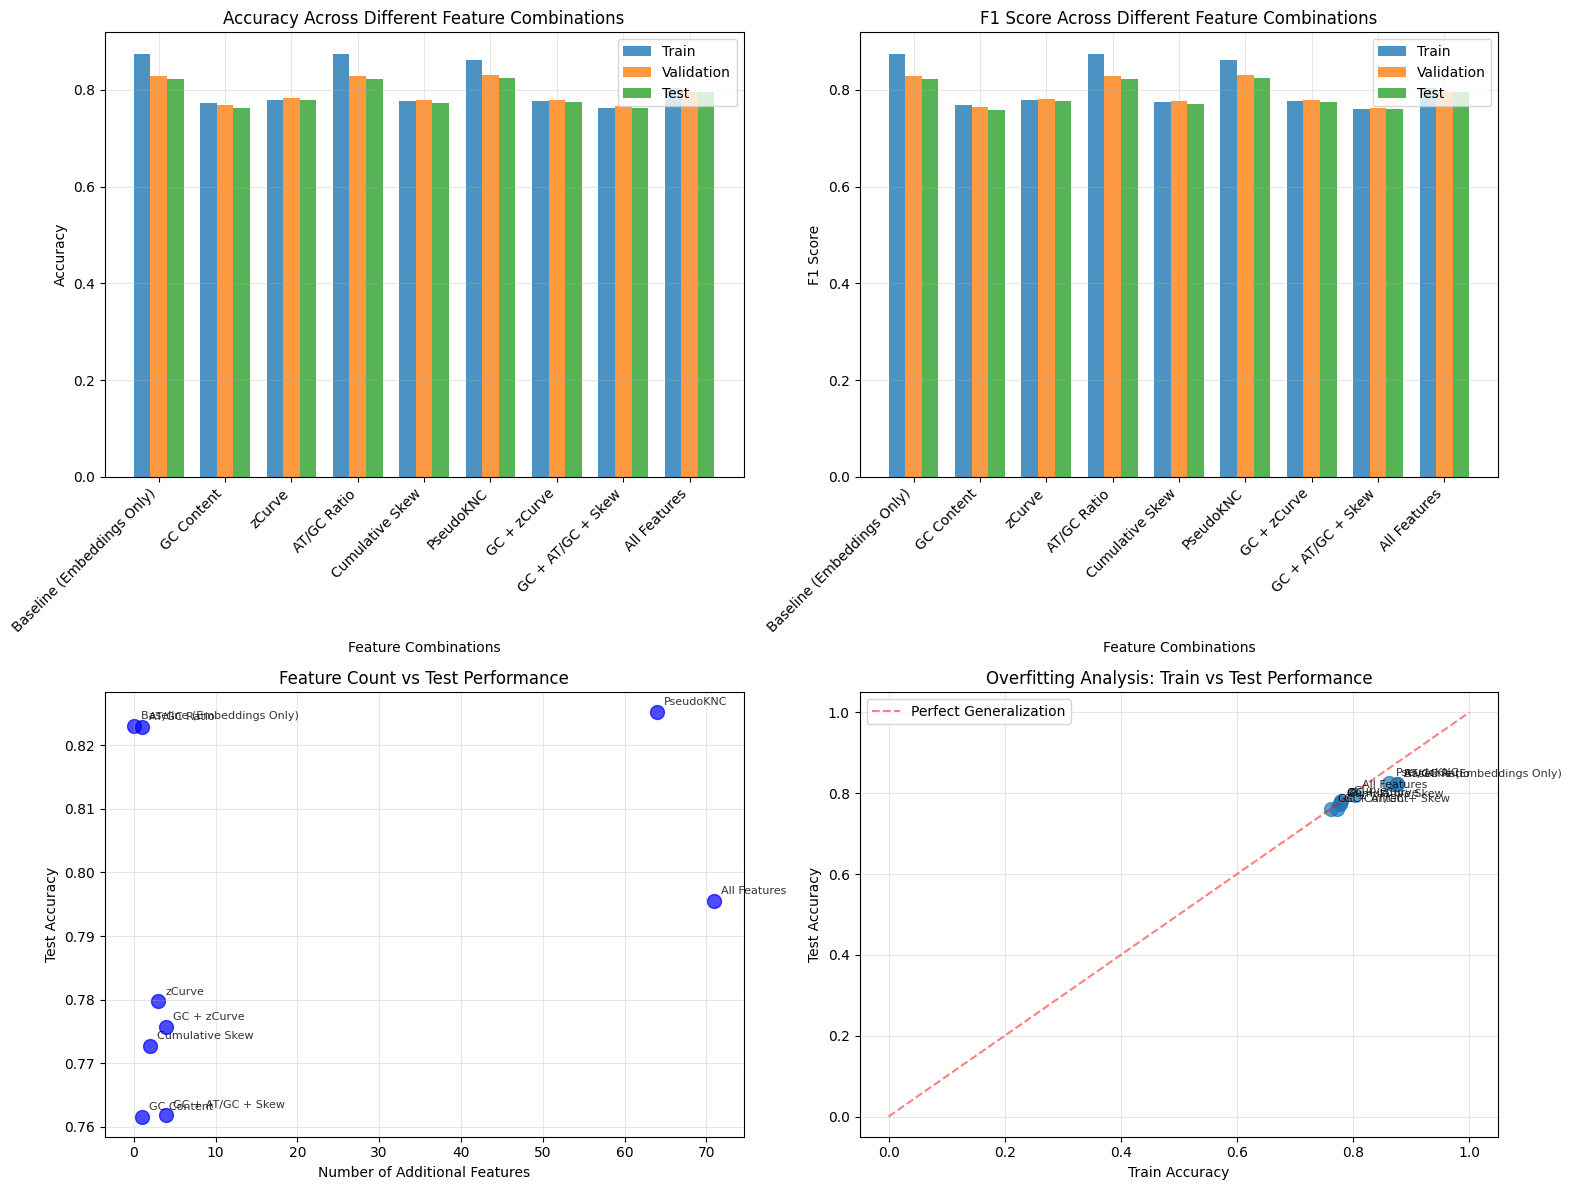


ABLATION STUDY RESULTS
Rank Feature Combination       Test Acc   Test F1    Val Acc    Generalization Gap
-------------------------------------------------------------------------------------
1    PseudoKNC                 0.8252     0.8251     0.8312     0.0358            
2    Baseline (Embeddings Onl  0.8230     0.8228     0.8285     0.0523            
3    AT/GC Ratio               0.8229     0.8228     0.8285     0.0524            
4    All Features              0.7955     0.7952     0.7965     0.0081            
5    zCurve                    0.7797     0.7781     0.7823     -0.0000           
6    GC + zCurve               0.7756     0.7755     0.7801     0.0017            
7    Cumulative Skew           0.7728     0.7706     0.7783     0.0048            
8    GC + AT/GC + Skew         0.7618     0.7595     0.7658     0.0003            
9    GC Content                0.7616     0.7590     0.7681     0.0104            

KEY INSIGHTS:
• Best performing combination: PseudoKNC
• Im

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Ablation Study and Convergence Analysis
# =============================================================================

# Split training data into train/validation for convergence analysis
train_seqs_split, val_seqs, train_labels_split, val_labels = train_test_split(
    train_seqs, train_labels, test_size=0.2, random_state=42, stratify=train_labels
)

# Create DataFrames for split data
train_split_df = pd.DataFrame({'sequence': train_seqs_split, 'target': train_labels_split})
val_split_df = pd.DataFrame({'sequence': val_seqs, 'target': val_labels})

# Generate embeddings for split datasets
print("Generating embeddings for train/validation split...")
train_split_df["embedding"] = train_split_df["sequence"].apply(embed_sequence)
val_split_df["embedding"] = val_split_df["sequence"].apply(embed_sequence)

# Define feature combinations for ablation study
feature_combinations = {
    'Baseline (Embeddings Only)': [],
    'GC Content': ['gcContent'],
    'zCurve': ['zCurve'],
    'AT/GC Ratio': ['atgcRatio'],
    'Cumulative Skew': ['cumulativeSkew'],
    'PseudoKNC': ['pseudoKNC'],
    'GC + zCurve': ['gcContent', 'zCurve'],
    'GC + AT/GC + Skew': ['gcContent', 'atgcRatio', 'cumulativeSkew'],
    'All Features': ['gcContent', 'zCurve', 'atgcRatio', 'cumulativeSkew', 'pseudoKNC']
}

# Store results for analysis
results = {'combination': [], 'train_acc': [], 'val_acc': [], 'test_acc': [], 
           'train_f1': [], 'val_f1': [], 'test_f1': [], 'feature_count': []}

print("Starting ablation study...")

for combo_name, feature_keys in feature_combinations.items():
    print(f"Evaluating: {combo_name}")
    
    if len(feature_keys) == 0:  # Baseline - embeddings only
        # Use normalized embeddings
        train_comb = normalize_embeddings(np.stack(train_split_df["embedding"].values))
        val_comb = normalize_embeddings(np.stack(val_split_df["embedding"].values))
        test_comb = normalize_embeddings(np.stack(test_df["embedding"].values))
        feature_count = 0
    else:
        # Extract and combine features
        selected_functions = [feature_functions[key] for key in feature_keys]
        
        # Extract features
        train_feat = train_split_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))
        val_feat = val_split_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))
        test_feat = test_df['sequence'].apply(lambda seq: extract_features(seq, selected_functions))
        
        # Convert to arrays and normalize
        train_feat = np.stack(train_feat.values)
        val_feat = np.stack(val_feat.values)
        test_feat = np.stack(test_feat.values)
        
        scaler = MinMaxScaler()
        train_feat_scaled = scaler.fit_transform(train_feat)
        val_feat_scaled = scaler.transform(val_feat)
        test_feat_scaled = scaler.transform(test_feat)
        
        # Combine with embeddings
        train_emb = normalize_embeddings(np.stack(train_split_df["embedding"].values))
        val_emb = normalize_embeddings(np.stack(val_split_df["embedding"].values))
        test_emb = normalize_embeddings(np.stack(test_df["embedding"].values))
        
        alpha_emb = 0.8
        beta_feat = 0.2
        
        train_comb = np.hstack([alpha_emb * train_emb, beta_feat * train_feat_scaled])
        val_comb = np.hstack([alpha_emb * val_emb, beta_feat * val_feat_scaled])
        test_comb = np.hstack([alpha_emb * test_emb, beta_feat * test_feat_scaled])
        
        feature_count = train_feat.shape[1]
    
    # Build FAISS index
    index = faiss.IndexFlatIP(train_comb.shape[1])
    index.add(train_comb)
    
    # Function to evaluate on a dataset
    def evaluate_dataset(query_embeddings, true_labels, k=5):
        distances, indices = index.search(query_embeddings, k)
        retrieved_labels = np.array(train_split_df.iloc[indices.flatten()]['target'].values).reshape(-1, k)
        
        # Majority voting
        from scipy.stats import mode
        predicted_labels, _ = mode(retrieved_labels, axis=1)
        predicted_labels = predicted_labels.squeeze()
        
        acc = accuracy_score(true_labels, predicted_labels)
        f1 = f1_score(true_labels, predicted_labels, average='weighted')
        return acc, f1
    
    # Evaluate on all sets
    train_acc, train_f1 = evaluate_dataset(train_comb, train_split_df['target'].values)
    val_acc, val_f1 = evaluate_dataset(val_comb, val_split_df['target'].values)
    test_acc, test_f1 = evaluate_dataset(test_comb, test_df['target'].values)
    
    # Store results
    results['combination'].append(combo_name)
    results['train_acc'].append(train_acc)
    results['val_acc'].append(val_acc)
    results['test_acc'].append(test_acc)
    results['train_f1'].append(train_f1)
    results['val_f1'].append(val_f1)
    results['test_f1'].append(test_f1)
    results['feature_count'].append(feature_count)
    
    print(f"  Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# =============================================================================
# Visualization
# =============================================================================

# Create figure with subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Convergence Plot - Accuracy
x_pos = range(len(results_df))
width = 0.25

ax1.bar([x - width for x in x_pos], results_df['train_acc'], width, label='Train', alpha=0.8)
ax1.bar(x_pos, results_df['val_acc'], width, label='Validation', alpha=0.8)
ax1.bar([x + width for x in x_pos], results_df['test_acc'], width, label='Test', alpha=0.8)

ax1.set_xlabel('Feature Combinations')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Across Different Feature Combinations')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['combination'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Convergence Plot - F1 Score
ax2.bar([x - width for x in x_pos], results_df['train_f1'], width, label='Train', alpha=0.8)
ax2.bar(x_pos, results_df['val_f1'], width, label='Validation', alpha=0.8)
ax2.bar([x + width for x in x_pos], results_df['test_f1'], width, label='Test', alpha=0.8)

ax2.set_xlabel('Feature Combinations')
ax2.set_ylabel('F1 Score')
ax2.set_title('F1 Score Across Different Feature Combinations')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df['combination'], rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Feature Count vs Performance
ax3.scatter(results_df['feature_count'], results_df['test_acc'], s=100, alpha=0.7, color='blue')
for i, combo in enumerate(results_df['combination']):
    ax3.annotate(combo, (results_df['feature_count'][i], results_df['test_acc'][i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

ax3.set_xlabel('Number of Additional Features')
ax3.set_ylabel('Test Accuracy')
ax3.set_title('Feature Count vs Test Performance')
ax3.grid(True, alpha=0.3)

# 4. Train vs Test Performance (Overfitting Analysis)
ax4.scatter(results_df['train_acc'], results_df['test_acc'], s=100, alpha=0.7)
ax4.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect Generalization')

for i, combo in enumerate(results_df['combination']):
    ax4.annotate(combo, (results_df['train_acc'][i], results_df['test_acc'][i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

ax4.set_xlabel('Train Accuracy')
ax4.set_ylabel('Test Accuracy')
ax4.set_title('Overfitting Analysis: Train vs Test Performance')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# Summary Statistics
# =============================================================================

print("\n" + "="*80)
print("ABLATION STUDY RESULTS")
print("="*80)

# Sort by test accuracy for ranking
results_sorted = results_df.sort_values('test_acc', ascending=False)

print(f"{'Rank':<4} {'Feature Combination':<25} {'Test Acc':<10} {'Test F1':<10} {'Val Acc':<10} {'Generalization Gap':<18}")
print("-" * 85)

for i, (_, row) in enumerate(results_sorted.iterrows()):
    gap = row['train_acc'] - row['test_acc']
    print(f"{i+1:<4} {row['combination'][:24]:<25} {row['test_acc']:<10.4f} {row['test_f1']:<10.4f} {row['val_acc']:<10.4f} {gap:<18.4f}")

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)

best_combo = results_sorted.iloc[0]
baseline = results_df[results_df['combination'] == 'Baseline (Embeddings Only)'].iloc[0]

improvement = best_combo['test_acc'] - baseline['test_acc']
print(f"• Best performing combination: {best_combo['combination']}")
print(f"• Improvement over baseline: {improvement:.4f} ({improvement*100:.2f}%)")

# Find least overfitting combination
results_df['generalization_gap'] = results_df['train_acc'] - results_df['test_acc']
best_generalization = results_df.loc[results_df['generalization_gap'].idxmin()]
print(f"• Best generalization: {best_generalization['combination']} (gap: {best_generalization['generalization_gap']:.4f})")

# Feature contribution analysis
single_features = ['GC Content', 'zCurve', 'AT/GC Ratio', 'Cumulative Skew', 'PseudoKNC']
print(f"\n• Individual feature contributions (vs baseline):")
for feat in single_features:
    if feat in results_df['combination'].values:
        feat_performance = results_df[results_df['combination'] == feat]['test_acc'].iloc[0]
        contribution = feat_performance - baseline['test_acc']
        print(f"  - {feat}: {contribution:+.4f}")

print("\n🎯 Analysis complete!")